# Part A: Data Exploration, Visualisation And Analytics (Using Apache Spark) (40%) 

In [72]:
# CTEC3702_Week2_Lab2_Rdds_and_DataFrams_in_PySpark
!pip install pyspark                                  # Installs the PySpark library for distributed data processing using Apache Spark.


In [35]:
# CTEC3702_Week2_Lab2_Rdds_and_DataFrames_in_PySpark
# Lab 3.3
# Import the necessary libraries and initialize a Spark session
from pyspark.sql import SparkSession

# Creates a Spark session named 'UK_Crime_Data_Preprocessing' using 2 local CPU cores for running Spark operations.
spark = (
    SparkSession.builder
        .master("local[2]")
        .appName("UK_Crime_Data_Preprocessing")
        .getOrCreate()
)

# Prints out the output when spark session has been created
print("Spark Session for Part A UK_Crime_Data_Preprocessing has been created")


Spark Session for Part A UK_Crime_Data_Preprocessing has been created


# Task 1: Loading and Preprocessing the Dataset (10%)

# 1a- Load the Dataset (4%)

In [36]:
# CTEC3702_Week2_Lab3_Rdds_and_DataFrams_andSQL_in_PySpark
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# Week 3 - Lab 3.3

# Load all monthly CSV files (2023–2024) for Derbyshire, Leicestershire and Nottinghamshire
crime_df = spark.read.csv(
    "/kaggle/input/ctec3702parta-and-bcw/UK Police Crime Data 20232024/*/*.csv", # Specifies the file path pattern to read all CSV files from subfolders within the given directory.
    header=True, # Specifies that the first row of the dataset contains column names (headers).
    inferSchema=True # Automatically detects and assigns data types to each column in the dataset.
)

# Display first 5 rows
crime_df.show(5)





+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+
|            Crime ID|              Month|         Reported by|        Falls within|Longitude| Latitude|            Location|LSOA code|        LSOA name|          Crime type|Last outcome category|Context|
+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+
|58047a3a95167140d...|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.347639|53.061766|On or near Regent...|E01019444|Amber Valley 003B|Violence and sexu...| Court result unav...|   NULL|
|8ac857a6be54f5424...|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.329102|53.024519|On or near Minkle...|E01019451|Amber Valley 012D|               Drugs| Unabl

In [37]:
# Prints the total number of rows in the DataFrame - crime_df.
print("Total rows in DataFrame:", crime_df.count())

Total rows in DataFrame: 695700


# Guidance Note : Column Renaming & Missing Values 

In [39]:
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# Week 3 - Lab 3.3

# Renaming the columns in the DataFrame for consistency
crime_df = crime_df.toDF( # Converts the existing crime_df DataFrame to a new one, allowing for renaming or modification of its column name)
    "Crime_ID", 
    "Month", 
    "Reported_By", 
    "Falls_Within", 
    "Longitude", 
    "Latitude", 
    "Location", 
    "LSOA_Code", 
    "LSOA_Name", 
    "Crime_Type", 
    "Last_Outcome_Category", 
    "Context"
)

# Show the updated column names and a few rows
crime_df.show(5)


+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+
|            Crime_ID|              Month|         Reported_By|        Falls_Within|Longitude| Latitude|            Location|LSOA_Code|        LSOA_Name|          Crime_Type|Last_Outcome_Category|Context|
+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+
|58047a3a95167140d...|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.347639|53.061766|On or near Regent...|E01019444|Amber Valley 003B|Violence and sexu...| Court result unav...|   NULL|
|8ac857a6be54f5424...|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.329102|53.024519|On or near Minkle...|E01019451|Amber Valley 012D|               Drugs| Unabl

# Check for Missing  Values

In [41]:
# This code checks every column in the DataFrame and counts how many values are missing (null, empty, or NaN). 
# It stores these counts in a new DataFrame called missing_values and then displays the results.

# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
from pyspark.sql.functions import col, when, count, isnan, lit                                                                    # Imports PySpark SQL functions used for column operations, conditional logic, counting, checking missing values, and creating constant columns.

# Counts missing or invalid values (nulls, empty strings, or NaNs) in each column of crime_df and stores the results in a new DataFrame called missing_values.
missing_values = crime_df.select([                                                                                                 # Creates a new DataFrame missing_values by selecting columns from crime_df to check for missing data in each column.
    count(
        when(
            col(c).isNull() | (col(c) == "") |                                                                                     # Checks whether a column value is null or an empty string.
            when(col(c).cast("string").isNotNull(), isnan(col(c).cast("double"))).otherwise(lit(False)),                           # If the column isn’t null, this checks whether its value is NaN , otherwise, it returns False.
            c
        )
    ).alias(c)                                                                                                                     # Assigns the column’s original name as the alias for the calculated missing value count.
    for c in crime_df.columns                                                                                                      # Loops through each column name in the crime_df DataFrame.
])

# Displays the contents of the new missing_values DataFrame.
missing_values.show()




+--------+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+-------+
|Crime_ID|Month|Reported_By|Falls_Within|Longitude|Latitude|Location|LSOA_Code|LSOA_Name|Crime_Type|Last_Outcome_Category|Context|
+--------+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+-------+
|  110275|    0|          0|           0|     8746|    8746|       0|     8746|     8746|         0|               110275| 695700|
+--------+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+-------+



# Handle Missing Values

In [43]:
# This code cleans the dataset by removing unnecessary columns, dropping rows with missing location values, & filling missing outcome categories with 'Unknown'
# It prepares the DataFrame for analysis by making sure that the remaining data is complete and usable.

# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL

from pyspark.sql import functions as F

# Drop the Crime_ID column (identifier, not useful for analysis)
crime_df = crime_df.drop("Crime_ID")

# Drops rows that have missing values in columns
crime_df = crime_df.na.drop(subset=["Longitude", "Latitude", "LSOA_Code", "LSOA_Name"])

# Replaces missing values in the Last_Outcome_Category column with the word "Unknown".
crime_df = crime_df.na.fill({"Last_Outcome_Category": "Unknown"})

# Drop the Context column
crime_df = crime_df.drop("Context")

# Verify the cleaning results
crime_df.show(5)



+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+
|              Month|         Reported_By|        Falls_Within|Longitude| Latitude|            Location|LSOA_Code|        LSOA_Name|          Crime_Type|Last_Outcome_Category|
+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+
|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.347639|53.061766|On or near Regent...|E01019444|Amber Valley 003B|Violence and sexu...| Court result unav...|
|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.329102|53.024519|On or near Minkle...|E01019451|Amber Valley 012D|               Drugs| Unable to prosecu...|
|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.338044|53.027688|On or near Oakes ...|E01019451|Amber 

In [44]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Counts and displays the number of null values in each column of crime_df.
crime_df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in crime_df.columns]).show()

+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+
|Month|Reported_By|Falls_Within|Longitude|Latitude|Location|LSOA_Code|LSOA_Name|Crime_Type|Last_Outcome_Category|
+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+
|    0|          0|           0|        0|       0|       0|        0|        0|         0|                    0|
+-----+-----------+------------+---------+--------+--------+---------+---------+----------+---------------------+



In [45]:
# Prints the total number of rows in crime_df after data cleaning.
print("Rows after cleaning:", crime_df.count())

Rows after cleaning: 686954


# 1b- Extract and Standardise County Names (6%)

In [46]:
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# This code creates a new ‘county’ column by mapping each police force name in the reported_by column to its corresponding county. 
# It uses conditional logic (F.when) to assign Derbyshire, Leicestershire, or Nottinghamshire based on the police force.

from pyspark.sql import functions as F  # Imports PySpark’s SQL functions module and gives it the alias F for easier use.

# Create a new column called 'county' based on the 'reported_by' column
crime_df = crime_df.withColumn(                                                                         # Creates a column in crime_df with a new column definition or transformation.
    "county",
    F.when(F.col("reported_by") == "Derbyshire Constabulary", "Derbyshire")                             # Creates a conditional expression that returns "Derbyshire" when the reported_by column equals "Derbyshire Constabulary".
     .when(F.col("reported_by") == "Leicestershire Police", "Leicestershire")                           # Adds another condition that returns "Leicestershire" when reported_by equals "Leicestershire Police".
     .when(F.col("reported_by") == "Nottinghamshire Police", "Nottinghamshire")                         # Adds a condition that returns "Nottinghamshire" when reported_by equals "Nottinghamshire Police".
)
crime_df.show()

+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+---------------+
|              Month|         Reported_By|        Falls_Within|Longitude| Latitude|            Location|LSOA_Code|        LSOA_Name|          Crime_Type|Last_Outcome_Category|         county|
+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+---------------+
|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.347639|53.061766|On or near Regent...|E01019444|Amber Valley 003B|Violence and sexu...| Court result unav...|Nottinghamshire|
|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.329102|53.024519|On or near Minkle...|E01019451|Amber Valley 012D|               Drugs| Unable to prosecu...|Nottinghamshire|
|2023-05-01 00:00:00|Nottinghamshire P..

In [47]:
# Displays all unique combinations of the reported_by and county columns from crime_df.
crime_df.select("reported_by", "county").distinct().show()                         

+--------------------+---------------+
|         reported_by|         county|
+--------------------+---------------+
|Leicestershire Po...| Leicestershire|
|Nottinghamshire P...|Nottinghamshire|
|Derbyshire Consta...|     Derbyshire|
+--------------------+---------------+



# Task 2: Descriptive Data Analysis using Spark SQL (15%) 


# 2a - Total Crimes by County (5%)
# Write a Spark SQL query to calculate the total number of crimes reported in each county for 2023 and 2024.

In [48]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL - Additional Challenge
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# Lab 3.3

# This query counts the total number of crimes per county for each year by extracting the year from the month column and grouping the data accordingly. 
# It filters out rows without a county and returns a sorted summary of yearly crime totals by county.

# Create a temporary SQL view so we can run SQL queries on the DataFrame
crime_df.createOrReplaceTempView("crimes")

# Counts the total number of crimes per county for each year (based on the month column).
# Displays the results ordered by county and year, excluding any records with a missing county name.
# Run an SQL query to count total crimes per county per year
spark.sql("""
SELECT 
    county,                              -- County name
    SUBSTRING(month, 1, 4) AS year,      -- Month column used, 1 takes first character, 4 is the number of characters being extracted
    COUNT(*) AS total_crimes             -- Count total number of crimes
FROM crimes                              -- From Crime Table
WHERE county IS NOT NULL                 -- Exclude rows without a county name
GROUP BY county, SUBSTRING(month, 1, 4)  -- Group by county and year
ORDER BY county, year                    -- Sort results by county and year
""").show()


+---------------+----+------------+
|         county|year|total_crimes|
+---------------+----+------------+
|     Derbyshire|2023|      114103|
|     Derbyshire|2024|      105236|
| Leicestershire|2023|      106465|
| Leicestershire|2024|      104753|
|Nottinghamshire|2023|      133601|
|Nottinghamshire|2024|      122796|
+---------------+----+------------+



# The table shows the total number of crimes recorded in each county during 2023 and 2024. Nottinghamshire has the highest crime counts in both years, while Leicestershire records the lowest overall figures. Derbyshire and Nottinghamshire both show a slight decrease in 2024, suggesting a small improvement in reported crime levels.

# 2 - Monthly Crime Trends (5%)

In [49]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL

# This query calculates the total number of crimes for each county by year and month by extracting the year and month from the date column.
# It groups and sorts the results to show monthly crime trends for every county.

# Create a temporary SQL view so we can query the DataFrame using SQL
crime_df.createOrReplaceTempView("crimes")

# Run an SQL query to count total crimes by county, year, and month
spark.sql("""
SELECT 
    county,                                -- County name
    SUBSTRING(month, 1, 4) AS year,        -- Month column used, 1 takes first character, 4 is the number of characters being extracted
    SUBSTRING(month, 6, 2) AS month,       -- Month column used, 6 takes 6th character, 2 is the number of characters being extracted
    COUNT(*) AS total_crimes               -- Count total crimes
FROM crimes
WHERE county IS NOT NULL                   -- Ignore rows without a county
GROUP BY county, SUBSTRING(month, 1, 4), SUBSTRING(month, 6, 2)  -- Group by county, year, and month
ORDER BY county, year, month               -- Sort results for readability
""").show(72, truncate=False)              # Show up to 72 rows without truncating text

# Guidance Note Save key tables (e.g., crimes per year or month).
# Groups the data by county and month-year, counts the number of crimes in each group, merges the output into one file, and saves it as a CSV with headers.
crime_df.groupBy("county", F.substring("month",1,7).alias("month_year")).count().coalesce(1).write.csv("/kaggle/working/min_maxcrimeby_month", header=True)                 

+---------------+----+-----+------------+
|county         |year|month|total_crimes|
+---------------+----+-----+------------+
|Derbyshire     |2023|01   |8884        |
|Derbyshire     |2023|02   |9156        |
|Derbyshire     |2023|03   |9982        |
|Derbyshire     |2023|04   |10151       |
|Derbyshire     |2023|05   |10744       |
|Derbyshire     |2023|06   |10423       |
|Derbyshire     |2023|07   |10152       |
|Derbyshire     |2023|08   |9992        |
|Derbyshire     |2023|09   |9388        |
|Derbyshire     |2023|10   |8933        |
|Derbyshire     |2023|11   |8169        |
|Derbyshire     |2023|12   |8129        |
|Derbyshire     |2024|01   |8216        |
|Derbyshire     |2024|02   |8902        |
|Derbyshire     |2024|03   |8910        |
|Derbyshire     |2024|04   |8809        |
|Derbyshire     |2024|05   |9491        |
|Derbyshire     |2024|06   |9646        |
|Derbyshire     |2024|07   |9543        |
|Derbyshire     |2024|08   |9223        |
|Derbyshire     |2024|09   |8724  

# The table above shows monthly crime counts for each county across 2023 and 2024. Nottinghamshire consistently reports the highest number of crimes each month, followed by Derbyshire and Leicestershire. All three counties show slight seasonal variation, with crime levels generally higher between April and August and lower towards the end of the year.

# 2B (1) - Monthly Crime Trends (5%) 

# Write a Spark SQL query to calculate the total number of crimes per year and month for each county, ordered in descending order.

In [50]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# Create a temporary SQL view so we can run SQL queries on the DataFrame


# Creates a temporary SQL view named crimes from crime_df.
# Selects the year and month from the month column, counts total crimes for Derbyshire, groups results by year and month, and sorts them in descending order of total crimes.
# Displays the top 24 rows without truncating any column values.

crime_df.createOrReplaceTempView("crimes")

# === Derbyshire ===
print(" Derbyshire Monthly Crimes")
spark.sql("""
SELECT 
    SUBSTRING(month, 1, 4) AS year,
    SUBSTRING(month, 6, 2) AS month,
    COUNT(*) AS total_crimes
FROM crimes
WHERE county = 'Derbyshire'
GROUP BY year, month
ORDER BY total_crimes DESC              -- Sorts the results in descending order based on the total_crimes column (from highest to lowest).
""").show(24, truncate=False)


 Derbyshire Monthly Crimes


+----+-----+------------+
|year|month|total_crimes|
+----+-----+------------+
|2023|05   |10744       |
|2023|06   |10423       |
|2023|07   |10152       |
|2023|04   |10151       |
|2023|08   |9992        |
|2023|03   |9982        |
|2024|06   |9646        |
|2024|07   |9543        |
|2024|05   |9491        |
|2023|09   |9388        |
|2024|08   |9223        |
|2023|02   |9156        |
|2024|10   |9066        |
|2023|10   |8933        |
|2024|03   |8910        |
|2024|02   |8902        |
|2023|01   |8884        |
|2024|04   |8809        |
|2024|09   |8724        |
|2024|01   |8216        |
|2023|11   |8169        |
|2023|12   |8129        |
|2024|12   |7742        |
|2024|11   |6964        |
+----+-----+------------+



# For Derbyshire, the table shows the total number of crimes recorded each month in 2023 and 2024. The highest crime levels occurred in mid 2023, particularly between April and July, with a peak of over 10,700 crimes in May 2023. Crime numbers gradually decline through late 2023 and into 2024, suggesting a downward trend and reduced crime activity towards the end of the period.

# 2b (2) - Month in which maximum number of crimes took place in Derbyshire during 2023 and 2024

In [52]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Register the DataFrame as a temporary SQL table
crime_df.createOrReplaceTempView("crime_table")

# SQL query to find the month with the maximum number of crimes in Derbyshire
# Filters data for Derbyshire, groups crimes by month, and counts total crimes per month.
# Sorts the results in descending order to find the month with the highest crime count.
# Displays only the top result labeled as "Maximum Crime Month".

spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Derbyshire,
    'Maximum Crime Month' AS Crime_Month_Type
FROM 
    crime_table
WHERE 
    county = 'Derbyshire'
GROUP BY 
    Month
ORDER BY 
    Crimes_per_Month_Derbyshire DESC
LIMIT 1
""").show()


+-------------------+---------------------------+-------------------+
|              Month|Crimes_per_Month_Derbyshire|   Crime_Month_Type|
+-------------------+---------------------------+-------------------+
|2023-05-01 00:00:00|                      10744|Maximum Crime Month|
+-------------------+---------------------------+-------------------+



 # 2b (2)- Month in which minimum number of crimes took place in Derbshire during 2023 and 2024

In [53]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# This query finds the month in Derbyshire with the lowest number of crimes by counting crimes per month and sorting in ascending order. 
# It then returns only the month with the minimum crime count.

# Register the DataFrame as a temporary SQL view
crime_df.createOrReplaceTempView("crime_table")

# SQL query to find the month with the minimum number of crimes in Derbyshire
spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Derbyshire,
    'Minimum Crime Month' AS Crime_Month_Type
FROM 
    crime_table
WHERE 
    county = 'Derbyshire'
GROUP BY 
    Month
ORDER BY 
    Crimes_per_Month_Derbyshire ASC
LIMIT 1
""").show()


+-------------------+---------------------------+-------------------+
|              Month|Crimes_per_Month_Derbyshire|   Crime_Month_Type|
+-------------------+---------------------------+-------------------+
|2024-11-01 00:00:00|                       6964|Minimum Crime Month|
+-------------------+---------------------------+-------------------+



In [54]:
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL

# This query extracts the year and month for Leicestershire and counts the total crimes in each month.
# It then sorts the results in descending order to show the months with the highest crime levels first.

# Leicestershire 
print("Leicestershire Monthly Crimes")
spark.sql("""
SELECT 
    SUBSTRING(month, 1, 4) AS year,
    SUBSTRING(month, 6, 2) AS month,
    COUNT(*) AS total_crimes
FROM crimes
WHERE county = 'Leicestershire'
GROUP BY year, month
ORDER BY total_crimes DESC
""").show(24, truncate=False)


Leicestershire Monthly Crimes


+----+-----+------------+
|year|month|total_crimes|
+----+-----+------------+
|2023|05   |9564        |
|2023|06   |9494        |
|2023|04   |9332        |
|2024|07   |9265        |
|2023|03   |9216        |
|2024|06   |9167        |
|2024|05   |9116        |
|2024|08   |9045        |
|2023|08   |8986        |
|2023|07   |8973        |
|2024|10   |8886        |
|2024|04   |8872        |
|2023|09   |8862        |
|2023|10   |8847        |
|2024|09   |8813        |
|2024|11   |8809        |
|2024|03   |8636        |
|2023|02   |8422        |
|2023|11   |8392        |
|2023|01   |8348        |
|2024|01   |8092        |
|2024|12   |8053        |
|2023|12   |8029        |
|2024|02   |7999        |
+----+-----+------------+



# For Leicestershire, crime levels were highest during spring and early summer months, particularly between March and June 2023, peaking at around 9,800 crimes in May 2023. The figures show a gradual decrease in late 2023 and into 2024, with the lowest numbers appearing in the winter months. This pattern suggests that crime activity in Leicestershire tends to rise during warmer months and drop towards the year’s end.

 # 2b (2)- Month in which maximum number of crimes took place in Leicestershire during 2023 and 2024

In [55]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Register the DataFrame as a temporary SQL view
crime_df.createOrReplaceTempView("crime_table")

# Finds the month with the highest number of crimes in Leicestershire by counting crimes per month, sorting them in descending order, 
# and displaying only the top result labeled as "Maximum Crime Month".

# SQL query for maximum number of crimes in Leicestershire
spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Leicestershire,
    'Maximum Crime Month' AS Crime_Month_Type
FROM 
    crime_table
WHERE 
    county = 'Leicestershire'
GROUP BY 
    Month
ORDER BY 
    Crimes_per_Month_Leicestershire DESC
LIMIT 1
""").show()


+-------------------+-------------------------------+-------------------+
|              Month|Crimes_per_Month_Leicestershire|   Crime_Month_Type|
+-------------------+-------------------------------+-------------------+
|2023-05-01 00:00:00|                           9564|Maximum Crime Month|
+-------------------+-------------------------------+-------------------+



 # 2b (2)- Month in which minimum number of crimes took place in Leicestershire during 2023 and 2024

In [56]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL

# This query identifies the month with the lowest crime count in Leicestershire by grouping crimes by month and sorting the totals in ascending order. 
# It then returns only the month with the minimum number of crimes.
spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Leicestershire,
    'Minimum Crime Month' AS Crime_Month_Type
FROM 
    crime_table
WHERE 
    county = 'Leicestershire'
GROUP BY 
    Month
ORDER BY 
    Crimes_per_Month_Leicestershire ASC
LIMIT 1
""").show()


+-------------------+-------------------------------+-------------------+
|              Month|Crimes_per_Month_Leicestershire|   Crime_Month_Type|
+-------------------+-------------------------------+-------------------+
|2024-02-01 00:00:00|                           7999|Minimum Crime Month|
+-------------------+-------------------------------+-------------------+



In [57]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL

# This query extracts the year and month for Nottinghamshire and counts how many crimes occurred in each month.
# It then sorts the results in descending order to highlight the months with the highest crime levels.

# Nottinghamshire
print("Nottinghamshire Monthly Crimes")
spark.sql("""
SELECT 
    SUBSTRING(month, 1, 4) AS year,
    SUBSTRING(month, 6, 2) AS month,
    COUNT(*) AS total_crimes
FROM crimes
WHERE county = 'Nottinghamshire'
GROUP BY year, month
ORDER BY total_crimes DESC
""").show(24, truncate=False)


Nottinghamshire Monthly Crimes


+----+-----+------------+
|year|month|total_crimes|
+----+-----+------------+
|2023|05   |12385       |
|2023|06   |12265       |
|2023|07   |11784       |
|2023|04   |11659       |
|2024|07   |11616       |
|2023|03   |11547       |
|2024|05   |11459       |
|2023|08   |11375       |
|2023|09   |11201       |
|2023|10   |11005       |
|2024|08   |10829       |
|2023|02   |10807       |
|2023|01   |10575       |
|2024|06   |10573       |
|2024|03   |10390       |
|2024|10   |10320       |
|2024|01   |10016       |
|2023|11   |9990        |
|2024|04   |9937        |
|2024|11   |9882        |
|2024|02   |9533        |
|2024|12   |9381        |
|2023|12   |9008        |
|2024|09   |8860        |
+----+-----+------------+



 # 2b (2)- Month in which maximum number of crimes took place in Nottinghamshire during 2023 and 2024

In [58]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Register the DataFrame as a temporary SQL view
crime_df.createOrReplaceTempView("crime_table")

# This query finds the month with the highest crime count in Nottinghamshire by grouping crimes by month and sorting the totals in descending order.
# It then returns only the month with the maximum number of crimes.

# SQL query to find the month with the maximum number of crimes in Nottinghamshire
spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Nottinghamshire,
    'Maximum Crime Month' AS Crime_Month_Type
FROM 
    crime_table
WHERE 
    county = 'Nottinghamshire'
GROUP BY 
    Month
ORDER BY 
    Crimes_per_Month_Nottinghamshire DESC
LIMIT 1
""").show()


+-------------------+--------------------------------+-------------------+
|              Month|Crimes_per_Month_Nottinghamshire|   Crime_Month_Type|
+-------------------+--------------------------------+-------------------+
|2023-05-01 00:00:00|                           12385|Maximum Crime Month|
+-------------------+--------------------------------+-------------------+



 # 2b (2)- Month in which minimum number of crimes took place in Nottinghamshire during 2023 and 2024

In [60]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL

# This query identifies the month with the lowest crime count in Nottinghamshire by grouping crimes by month and sorting the totals in ascending order. 
# It then returns only the month with the minimum number of crimes.

spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Nottinghamshire,
    'Minimum Crime Month' AS Crime_Month_Type
FROM 
    crime_table
WHERE 
    county = 'Nottinghamshire'
GROUP BY 
    Month
ORDER BY 
    Crimes_per_Month_Nottinghamshire ASC
LIMIT 1
""").show()


+-------------------+--------------------------------+-------------------+
|              Month|Crimes_per_Month_Nottinghamshire|   Crime_Month_Type|
+-------------------+--------------------------------+-------------------+
|2024-09-01 00:00:00|                            8860|Minimum Crime Month|
+-------------------+--------------------------------+-------------------+



# Nottinghamshire records the highest monthly crime totals among the three counties, with peak activity seen between April and July 2023 when crimes exceeded 12,000 per month. A noticeable decline occurs during the colder months of late 2023 and early 2024, with the lowest counts found in September and December 2024. Overall, the data shows a clear seasonal trend where crime levels rise during spring and summer and fall during winter.

# 2C- Crime Type Analysis (5%)


# 2C (1)- Write a Spark SQL query to calculate the most common and least common crime types in each county.

# Most frequently occured crime type in Derbyshire over the years 2023 & 2024

In [61]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# Register DataFrame as a temporary SQL table
crime_df.createOrReplaceTempView("crime_table")

# This query finds the most common crime type in Derbyshire by counting how many times each crime type appears. 
# It then sorts the counts in descending order and returns the crime type with the highest frequency.
spark.sql("""
SELECT 
    Crime_Type, 
    COUNT(*) AS Crimes_Per_Type_Derbyshire,
    'Maximum Crime Type' AS Crime_Type
FROM 
    crime_table
WHERE 
    county = 'Derbyshire'
GROUP BY 
    Crime_Type
ORDER BY 
    Crimes_Per_Type_Derbyshire DESC
LIMIT 1
""").show()


+--------------------+--------------------------+------------------+
|          Crime_Type|Crimes_Per_Type_Derbyshire|        Crime_Type|
+--------------------+--------------------------+------------------+
|Violence and sexu...|                     85816|Maximum Crime Type|
+--------------------+--------------------------+------------------+



# Least frequently occured crime type in Derbyshire over the years 2023 & 2024

In [63]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Register DataFrame as temporary SQL table
crime_df.createOrReplaceTempView("crime_table")

# This query identifies the least common crime type in Derbyshire by counting occurrences of each crime type. 
# It then sorts the results in ascending order and returns the crime type with the lowest count.
spark.sql("""
SELECT 
    Crime_Type, 
    COUNT(*) AS Crimes_Per_Type_Derbyshire,
    'Minimum Crime Type' AS Crime_Type
FROM 
    crime_table
WHERE 
    county = 'Derbyshire'
GROUP BY 
    Crime_Type
ORDER BY 
    Crimes_Per_Type_Derbyshire ASC
LIMIT 1
""").show()


+-------------+--------------------------+------------------+
|   Crime_Type|Crimes_Per_Type_Derbyshire|        Crime_Type|
+-------------+--------------------------+------------------+
|Bicycle theft|                      1152|Minimum Crime Type|
+-------------+--------------------------+------------------+



# Most frequently occured crime type in Leicestershire over the years 2023 & 2024

In [64]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Register DataFrame as a temporary SQL table
crime_df.createOrReplaceTempView("crime_table")

# This query finds the most frequent crime type in Leicestershire by counting how often each crime type occurs. 
# It then sorts the counts in descending order and returns the crime type with the highest total.
spark.sql("""
SELECT 
    Crime_Type, 
    COUNT(*) AS Crimes_Per_Type_Leicestershire,
    'Maximum Crime Type' AS Crime_Type
FROM 
    crime_table
WHERE 
    county = 'Leicestershire'
GROUP BY 
    Crime_Type
ORDER BY 
    Crimes_Per_Type_Leicestershire DESC
LIMIT 1
""").show()


+--------------------+------------------------------+------------------+
|          Crime_Type|Crimes_Per_Type_Leicestershire|        Crime_Type|
+--------------------+------------------------------+------------------+
|Violence and sexu...|                         78797|Maximum Crime Type|
+--------------------+------------------------------+------------------+



# Least frequently occured crime type in Leicestershire over the years 2023 & 2024

In [65]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Register DataFrame as temporary SQL table
crime_df.createOrReplaceTempView("crime_table")

# This query finds the least frequent crime type in Leicestershire by counting how many times each crime type appears.
# It then sorts the results in ascending order and returns the crime type with the lowest count.
spark.sql("""
SELECT 
    Crime_Type, 
    COUNT(*) AS Crimes_Per_Type_Leicestershire,
    'Minimum Crime Type' AS Crime_Type
FROM 
    crime_table
WHERE 
    county = 'Leicestershire'
GROUP BY 
    Crime_Type
ORDER BY 
    Crimes_Per_Type_Leicestershire ASC
LIMIT 1
""").show()


+----------+------------------------------+------------------+
|Crime_Type|Crimes_Per_Type_Leicestershire|        Crime_Type|
+----------+------------------------------+------------------+
|   Robbery|                          1635|Minimum Crime Type|
+----------+------------------------------+------------------+



# Most frequently occured crime type in Nottinghamshire over the years 2023 & 2024

In [67]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Register DataFrame as temporary SQL table
crime_df.createOrReplaceTempView("crime_table")

# This query identifies the most common crime type in Nottinghamshire by counting how often each crime type occurs.
# It then sorts the counts in descending order and returns the crime type with the highest frequency.
spark.sql("""
SELECT 
    Crime_Type, 
    COUNT(*) AS Crimes_Per_Type_Nottinghamshire,
    'Maximum Crime Type' AS Crime_Type
FROM 
    crime_table
WHERE 
    county = 'Nottinghamshire'
GROUP BY 
    Crime_Type
ORDER BY 
    Crimes_Per_Type_Nottinghamshire DESC
LIMIT 1
""").show()


+--------------------+-------------------------------+------------------+
|          Crime_Type|Crimes_Per_Type_Nottinghamshire|        Crime_Type|
+--------------------+-------------------------------+------------------+
|Violence and sexu...|                          75725|Maximum Crime Type|
+--------------------+-------------------------------+------------------+



# Least frequently occured crime type in Nottinghamshire over the years 2023 & 2024

In [68]:
# Register DataFrame as a temporary SQL table
crime_df.createOrReplaceTempView("crime_table")

# This query finds the least common crime type in Nottinghamshire by counting how many times each crime type appears. 
# It then sorts the counts in ascending order and returns the crime type with the lowest total.
spark.sql("""
SELECT 
    Crime_Type, 
    COUNT(*) AS Crimes_Per_Type_Nottinghamshire,
    'Minimum Crime Type' AS Crime_Type
FROM 
    crime_table
WHERE 
    county = 'Nottinghamshire'
GROUP BY 
    Crime_Type
ORDER BY 
    Crimes_Per_Type_Nottinghamshire ASC
LIMIT 1
""").show()


+--------------------+-------------------------------+------------------+
|          Crime_Type|Crimes_Per_Type_Nottinghamshire|        Crime_Type|
+--------------------+-------------------------------+------------------+
|Theft from the pe...|                           1885|Minimum Crime Type|
+--------------------+-------------------------------+------------------+



# 2C (2)- Rank the crime types by their frequency for each county.

In [69]:
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# Create or replace temp view
crime_df.createOrReplaceTempView("crimes")

# This query ranks all crime types in Derbyshire by counting how often each one occurs and assigning a rank based on frequency. 
# It then lists the crime types in order from most to least common.

# Run SQL query with ranking and county label
spark.sql("""
SELECT 
    'Derbyshire' AS county,                    -- Add county name for clarity
    crime_type,                                -- Type of crime 
    COUNT(*) AS total_crimes,                  -- Total number of crimes
    RANK() OVER (ORDER BY COUNT(*) DESC) AS rank  -- Rank crime types by frequency
FROM crimes
WHERE county = 'Derbyshire'                   -- Filter Derbyshire data
GROUP BY crime_type                           -- Group by crime type
ORDER BY rank ASC                             -- Sort by rank
""").show(50, truncate=False)


25/11/13 21:04:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:04:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:04:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:04:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:04:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:04:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 2

+----------+----------------------------+------------+----+
|county    |crime_type                  |total_crimes|rank|
+----------+----------------------------+------------+----+
|Derbyshire|Violence and sexual offences|85816       |1   |
|Derbyshire|Anti-social behaviour       |35537       |2   |
|Derbyshire|Public order                |21519       |3   |
|Derbyshire|Criminal damage and arson   |16416       |4   |
|Derbyshire|Other theft                 |14375       |5   |
|Derbyshire|Shoplifting                 |13826       |6   |
|Derbyshire|Vehicle crime               |8795        |7   |
|Derbyshire|Burglary                    |7541        |8   |
|Derbyshire|Drugs                       |5411        |9   |
|Derbyshire|Other crime                 |4335        |10  |
|Derbyshire|Possession of weapons       |2010        |11  |
|Derbyshire|Robbery                     |1341        |12  |
|Derbyshire|Theft from the person       |1265        |13  |
|Derbyshire|Bicycle theft               

# The table shows the total number of crimes by type across all counties. Violence and sexual offences make up the largest share, followed by anti-social behaviour and public order offences, indicating these are the most common issues in the region. Less frequent crimes include bicycle theft, robbery, and possession of weapons, which occur at much lower rates.

In [71]:
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# Create or replace temp view
crime_df.createOrReplaceTempView("crimes")


# This query ranks all crime types in Leicestershire by counting how many times each crime type appears. 
# It orders the results from most to least common based on the assigned rank.
spark.sql("""
SELECT 
    'Leicestershire' AS county,                    -- Add county name for clarity
    crime_type,                                -- Type of crime 
    COUNT(*) AS total_crimes,                  -- Total number of crimes
    RANK() OVER (ORDER BY COUNT(*) DESC) AS rank  -- Rank crime types by frequency
FROM crimes
WHERE county = 'Leicestershire'                   -- Only include Derbyshire data
GROUP BY crime_type                           -- Group by crime type
ORDER BY rank ASC                             -- Sort results by rank number
""").show(50, truncate=False)                 


25/11/13 21:05:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:05:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:05:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+--------------+----------------------------+------------+----+
|county        |crime_type                  |total_crimes|rank|
+--------------+----------------------------+------------+----+
|Leicestershire|Violence and sexual offences|78797       |1   |
|Leicestershire|Public order                |21330       |2   |
|Leicestershire|Anti-social behaviour       |19678       |3   |
|Leicestershire|Criminal damage and arson   |19388       |4   |
|Leicestershire|Other theft                 |16528       |5   |
|Leicestershire|Shoplifting                 |13710       |6   |
|Leicestershire|Vehicle crime               |13312       |7   |
|Leicestershire|Burglary                    |9998        |8   |
|Leicestershire|Drugs                       |6129        |9   |
|Leicestershire|Other crime                 |4509        |10  |
|Leicestershire|Bicycle theft               |2659        |11  |
|Leicestershire|Possession of weapons       |1859        |12  |
|Leicestershire|Theft from the person   

25/11/13 21:05:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:05:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:05:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:05:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


# This table displays the total crimes by type for Leicestershire. Violence and sexual offences are the most common, followed by public order and criminal damage and arson offences. Less frequent crimes such as robbery, theft from the person, and bicycle theft occur far less often, showing that most reported crimes are related to public safety and property damage.

In [75]:
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# Create or replace temp view
crime_df.createOrReplaceTempView("crimes")

# This query ranks all crime types in Nottinghamshire by counting how often each one occurs. 
# It then orders them from most to least common based on the assigned rank.
spark.sql("""
SELECT 
    'Nottinghamshire' AS County,
    crime_type,                                -- Type of crime 
    COUNT(*) AS total_crimes,                  -- Total number of crimes
    RANK() OVER (ORDER BY COUNT(*) DESC) AS rank  -- Rank crime types by frequency
FROM crimes
WHERE county = 'Nottinghamshire'                   -- Only include Derbyshire data
GROUP BY crime_type                           -- Group by crime type
ORDER BY rank ASC                             -- Sort results by rank number
""").show(50, truncate=False)                 # Show up to 50 rows without truncation


25/11/13 21:06:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:06:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:06:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------------+----------------------------+------------+----+
|County         |crime_type                  |total_crimes|rank|
+---------------+----------------------------+------------+----+
|Nottinghamshire|Violence and sexual offences|75725       |1   |
|Nottinghamshire|Anti-social behaviour       |55044       |2   |
|Nottinghamshire|Shoplifting                 |30152       |3   |
|Nottinghamshire|Criminal damage and arson   |20737       |4   |
|Nottinghamshire|Other theft                 |16411       |5   |
|Nottinghamshire|Public order                |15857       |6   |
|Nottinghamshire|Vehicle crime               |10606       |7   |
|Nottinghamshire|Burglary                    |8456        |8   |
|Nottinghamshire|Drugs                       |7931        |9   |
|Nottinghamshire|Other crime                 |5906        |10  |
|Nottinghamshire|Possession of weapons       |3182        |11  |
|Nottinghamshire|Bicycle theft               |2360        |12  |
|Nottinghamshire|Robbery 

25/11/13 21:06:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:06:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:06:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/13 21:06:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


# The table shows the total number of crimes by type for Nottinghamshire. Violence and sexual offences and anti-social behaviour are the most common offences, followed by shoplifting and criminal damage. Lower-frequency crimes such as robbery, theft from the person, and bicycle theft suggest these occur less often, indicating that most reported incidents involve personal or public disorder.

# Convert Spark DataFrames to Pandas

In [76]:
# Groups the data by month and counts the total number of crimes for each month.
# Stores the result as a Spark DataFrame named _crimes_per_month_COUNTYNAME.

# Derbyshire
Derbyshire_crimes_per_month = spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Derbyshire
FROM crime_table
WHERE county = 'Derbyshire'
GROUP BY Month
""")

# Leicestershire
Leicestershire_crimes_per_month = spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Leicestershire
FROM crime_table
WHERE county = 'Leicestershire'
GROUP BY Month
""")

# Nottinghamshire
Nottinghamshire_crimes_per_month = spark.sql("""
SELECT 
    Month, 
    COUNT(*) AS Crimes_per_Month_Nottinghamshire
FROM crime_table
WHERE county = 'Nottinghamshire'
GROUP BY Month
""")


In [77]:
# Convert each Spark DataFrame to Pandas Dataframe - allows for easier analysis and/or visualization
df_pandas_derbyshire_crimes_per_month = Derbyshire_crimes_per_month.toPandas()
df_pandas_leicestershire_crimes_per_month = Leicestershire_crimes_per_month.toPandas()
df_pandas_nottinghamshire_crimes_per_month = Nottinghamshire_crimes_per_month.toPandas()


In [78]:
# Week 3 - Lab 3.3

# This code combines the monthly crime DataFrames for the three counties into one table using an outer join on the “Month” column. 
# It uses reduce() to merge all DataFrames into a single final DataFrame.

# Import required libraries
from functools import reduce           # reduce() repeatedly applies a function to combine all items in a sequence into one value.           
import pandas as pd

# Merge the three county DataFrames into one combined DataFrame
number_of_crime_pandas_dfs = [
    df_pandas_derbyshire_crimes_per_month,
    df_pandas_leicestershire_crimes_per_month,
    df_pandas_nottinghamshire_crimes_per_month
]

# Week 3 - Lab 3.3
# Merges all DataFrames in number_of_crime_pandas_dfs into one DataFrame (number_of_crime_final_df) by matching the Month column using an outer join.
number_of_crime_final_df = reduce(
    lambda left, right: pd.merge(left, right, on=["Month"], how='outer'),
    number_of_crime_pandas_dfs
)


In [79]:
# Display the merged DataFrame
display(number_of_crime_final_df.head())


,Month,Crimes_per_Month_Derbyshire,Crimes_per_Month_Leicestershire,Crimes_per_Month_Nottinghamshire
0,2023-01-01,8884,8348,10575
1,2023-02-01,9156,8422,10807
2,2023-03-01,9982,9216,11547
3,2023-04-01,10151,9332,11659
4,2023-05-01,10744,9564,12385


# Task 3: Data Visualisation (15%) 


3A- Monthly Crime Trends (3%) - Line Plot

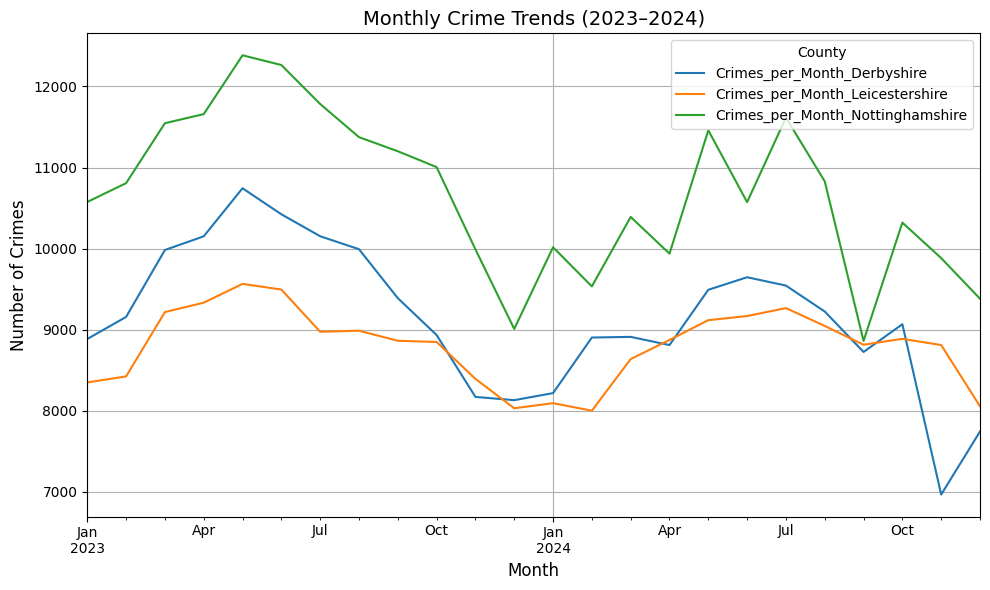

In [81]:
#CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
import matplotlib.pyplot as plt                                        # Imports the Matplotlib plotting library and gives it the alias plt for creating visualizations.

# Creates a line chart from the DataFrame with Month on the x-axis.
# Sets the figure size to 10×6 inches for better visibility.
number_of_crime_final_df.plot(
    kind="line",
    x="Month",
    figsize=(10,6)
)

# Sets axis labels, title, grid, and legend for the plot to make it clear and readable.
# Displays the final, well-formatted chart showing monthly crime trends.
plt.xlabel("Month", size=12)
plt.ylabel("Number of Crimes", size=12)
plt.title("Monthly Crime Trends (2023–2024)", size=14)
plt.grid(True)
plt.legend(title="County", loc="upper right")
plt.tight_layout()
plt.show()


# The line graph shows monthly crime trends for Derbyshire, Leicestershire, and Nottinghamshire from 2023 to 2024. Nottinghamshire consistently reports the highest crime levels, while Leicestershire has the lowest. All three counties follow a similar pattern, with peaks in mid 2023 (May 2023 is the highest) and a noticeable dip in crime rates toward early 2024.

In [83]:
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
from pyspark.sql.functions import count

# Filters the dataset to include only rows from COUNTY, groups them by crime type, and counts how many crimes occurred for each column type.


# This code calculates how many times each crime type occurs in each county by filtering the data for Derbyshire, Leicestershire, and Nottinghamshire separately. 
# It then groups by crime type and counts the total crimes for each category.

# Derbyshire: total crimes by type
Derbyshire_crime_type = (
    crime_df.filter(crime_df["county"] == "Derbyshire")
    .groupBy("Crime_Type")
    .agg(count("*").alias("Crimes_Per_Type_Derbyshire"))
)

# Leicestershire: total crimes by type
Leicestershire_crime_type = (
    crime_df.filter(crime_df["county"] == "Leicestershire")
    .groupBy("Crime_Type")
    .agg(count("*").alias("Crimes_Per_Type_Leicestershire"))
)

# Nottinghamshire: total crimes by type
Nottinghamshire_crime_type = (
    crime_df.filter(crime_df["county"] == "Nottinghamshire")
    .groupBy("Crime_Type")
    .agg(count("*").alias("Crimes_Per_Type_Nottinghamshire"))
)


In [84]:
# Convert each Spark DataFrame to Pandas Dataframe - allows for easier analysis and/or visualization
df_pandas_crime_type_derbyshire = Derbyshire_crime_type.toPandas()
df_pandas_crime_type_leicestershire = Leicestershire_crime_type.toPandas()
df_pandas_crime_type_nottinghamshire = Nottinghamshire_crime_type.toPandas()


# 3B- Crime Type Distribution (3%) - Bar Chart

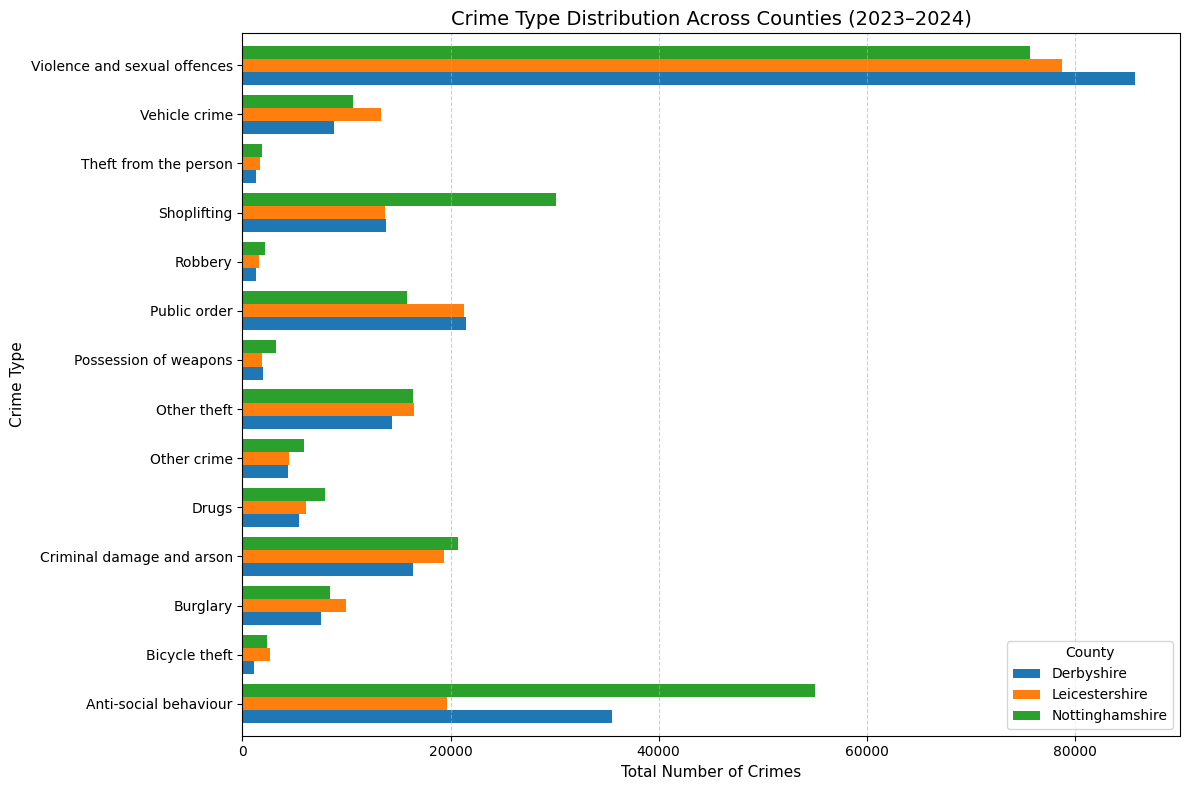

In [85]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
import matplotlib.pyplot as plt

# Runs an SQL query that groups all crimes by county and crime type, counts total crimes for each group,
# sorts them by county and crime count (highest first), and converts the result to a Pandas DataFrame.
crime_type_pd = spark.sql("""
SELECT 
    county,
    crime_type,
    COUNT(*) AS total_crimes
FROM crimes
GROUP BY county, crime_type
ORDER BY county, total_crimes DESC
""").toPandas()

# Transforms the DataFrame into a pivot table where each crime type is a row, each county is a column, and the cell values show the total number of crimes.
crime_type_pivot = crime_type_pd.pivot(index="crime_type", columns="county", values="total_crimes")

# Plot horizontal grouped bar chart
crime_type_pivot.plot(
    kind='barh',                      # Specifies that the chart should be a horizontal bar chart.
    figsize=(12, 8),
    width=0.8,
    color=["#1f77b4", "#ff7f0e", "#2ca02c"]  
)

# Label and format the chart
plt.title("Crime Type Distribution Across Counties (2023–2024)", fontsize=14)
plt.xlabel("Total Number of Crimes", fontsize=11)
plt.ylabel("Crime Type", fontsize=11)
plt.legend(title="County", loc="lower right")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# The bar chart compares crime type distribution across Derbyshire, Leicestershire, and Nottinghamshire for 2023–2024. Violence and sexual offences are the most common in all three counties, followed by anti-social behaviour and public order offences. Less frequent crimes such as bicycle theft, robbery, and possession of weapons occur at much lower rates, showing a consistent pattern of high personal and public disorder offences across the 3 couties.

# 3C - Crime Type Breakdown by County (6%) - Pie Chart

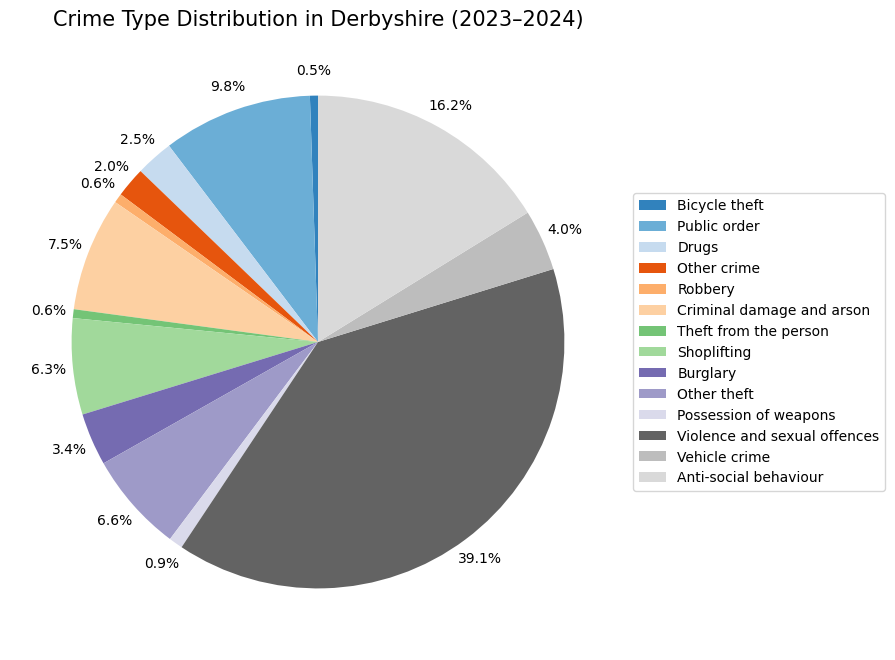

In [86]:
#CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
import matplotlib.pyplot as plt

# Generates a set of distinct colors from the 'tab20c' color map, matching the number of rows in df_pandas_crime_type_derbyshire, for use in plotting.
derby_colors = plt.get_cmap('tab20c', len(df_pandas_crime_type_derbyshire))(range(len(df_pandas_crime_type_derbyshire)))

#  Plot pie chart for Derbyshire
df_pandas_crime_type_derbyshire.plot(
    kind="pie",
    y="Crimes_Per_Type_Derbyshire",
    labels=None,
    figsize=(8,8),
    autopct="%.1f%%",
    startangle=90,
    colors=derby_colors,
    pctdistance=1.1
)

# Add legend and title
plt.legend(df_pandas_crime_type_derbyshire["Crime_Type"], loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Crime Type Distribution in Derbyshire (2023–2024)", size=15)
plt.ylabel("")  
plt.show()


# Derbyshire : Violence and sexual offences dominate, making up nearly 40% of all crimes, followed by anti-social behaviour and public order offences. Minor crimes such as bicycle theft and possession of weapons occur much less frequently, highlighting that most incidents are linked to personal and public safety.

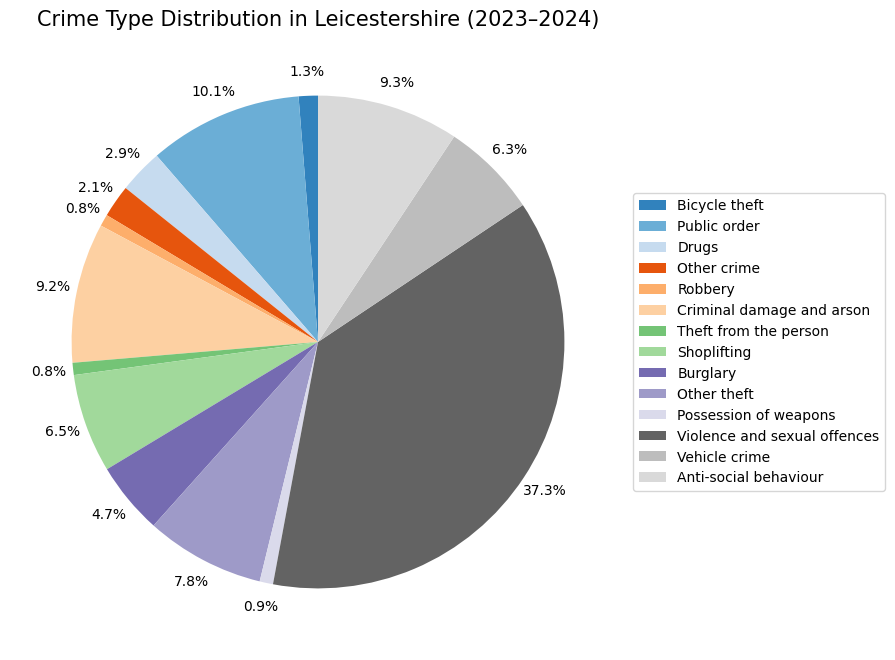

In [88]:
#CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
import matplotlib.pyplot as plt

# Generates a set of distinct colors from the 'tab20c' color map, matching the number of rows in df_pandas_crime_type_leicestershire, for use in plotting.
leicester_colors = plt.get_cmap('tab20c', len(df_pandas_crime_type_leicestershire))(range(len(df_pandas_crime_type_leicestershire)))

# Plot pie chart for Leicestershire
df_pandas_crime_type_leicestershire.plot(
    kind="pie",
    y="Crimes_Per_Type_Leicestershire",
    labels=None,
    figsize=(8,8),
    autopct="%.1f%%",
    startangle=90,
    colors=leicester_colors,
    pctdistance=1.1
)

#  Add legend and title
plt.legend(df_pandas_crime_type_leicestershire["Crime_Type"], loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Crime Type Distribution in Leicestershire (2023–2024)", size=15)
plt.ylabel("")  
plt.show()


# Leicestershire : Violence and sexual offences dominate, accounting for over a third of all reported crimes. Other notable categories include public order, criminal damage, and anti-social behaviour, while offences such as robbery and bicycle theft contribute only a small proportion.

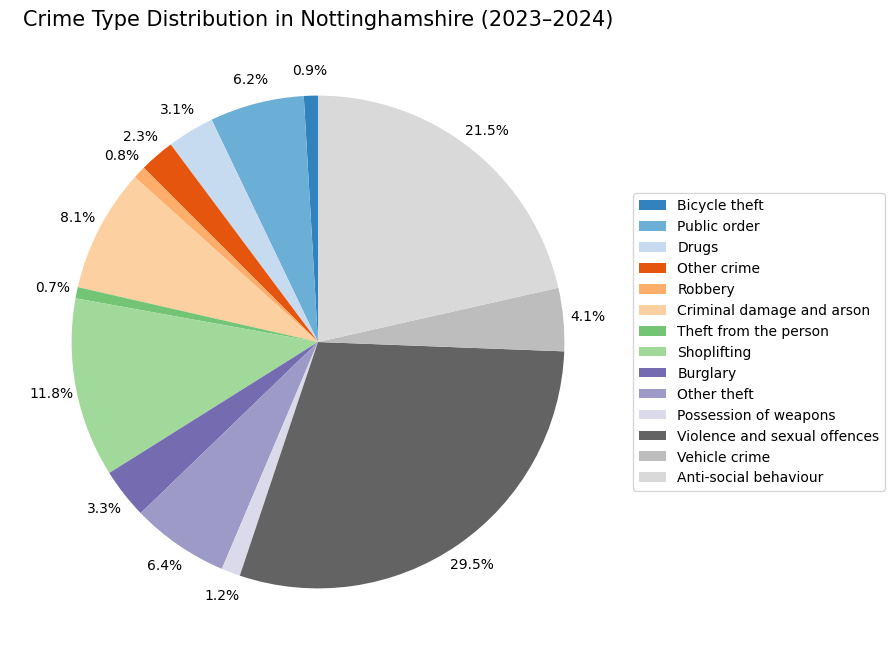

In [91]:
#CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
import matplotlib.pyplot as plt

# Generates a set of distinct colors from the 'tab20c' color map, matching the number of rows in df_pandas_crime_type_nottinghamshire, for use in plotting.
notts_colors = plt.get_cmap('tab20c', len(df_pandas_crime_type_nottinghamshire))(range(len(df_pandas_crime_type_nottinghamshire)))

# Plot pie chart for Nottinghamshire
df_pandas_crime_type_nottinghamshire.plot(
    kind="pie",
    y="Crimes_Per_Type_Nottinghamshire",
    labels=None,
    figsize=(8,8),
    autopct="%.1f%%",
    startangle=90,
    colors=notts_colors,
    pctdistance=1.1
)

#  Add legend and title
plt.legend(df_pandas_crime_type_nottinghamshire["Crime_Type"], loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Crime Type Distribution in Nottinghamshire (2023–2024)", size=15)
plt.ylabel("")  
plt.show()


# Nottinhamshire : Violence and sexual offences make up the largest proportion, followed by anti-social behaviour and shoplifting. Smaller categories like robbery, bicycle theft, and possession of weapons occur far less often, indicating that most reported crimes involve personal or public disorder.

In [92]:
# Stop the Spark session
spark.stop()

# Part B: Develop Solutions to machine learning problems (Using Apache Spark MlLib) (40%) 


# Starting Spark Session

In [1]:
# CTEC3702_Week2_Lab2_Rdds_and_DataFrames_in_PySpark
# Import the necessary libraries and initialize a Spark session
from pyspark.sql import SparkSession

# Creates a Spark session named "Loan_Prediction" using 2 local CPU cores to run Spark operations.
spark = (
    SparkSession.builder
        .master("local[2]")
        .appName("Loan_Prediction")
        .getOrCreate()
)

print("Spark Session for Part B Loan Prediction has been created")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/13 20:25:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session for Part B Loan Prediction has been created


# Task 1: Data Preprocessing (12%)

# Data Loading

In [2]:
# CTEC3702_Week4_Lab1_LoanPrediction_in_PySpark

# Reads all CSV files from the specified folder into a Spark DataFrame named loan_df, with column headers and automatically inferred data types.
loan_df = spark.read.csv(
    "/kaggle/input/ctec3702parta-and-bcw/Loan Prediction Dataset/Part B - Loan Prediction Dataset/*.csv",                 # Replace this file path with your own Kaggle dataset directory to load your data
    header=True,
    inferSchema=True
)

# Show first few rows
loan_df.show(5)



+--------+------+-------+----------+------------+-------------+---------------+-----------------+----------+----------------+--------------+-------------+-----------+
| Loan_ID|Gender|Married|Dependents|   Education|Self_Employed|ApplicantIncome|CoapplicantIncome|LoanAmount|Loan_Amount_Term|Credit_History|Property_Area|Loan_Status|
+--------+------+-------+----------+------------+-------------+---------------+-----------------+----------+----------------+--------------+-------------+-----------+
|LP001002|  Male|     No|         0|    Graduate|           No|           5849|              0.0|      NULL|             360|             1|        Urban|          Y|
|LP001003|  Male|    Yes|         1|    Graduate|           No|           4583|           1508.0|       128|             360|             1|        Rural|          N|
|LP001005|  Male|    Yes|         0|    Graduate|          Yes|           3000|              0.0|        66|             360|             1|        Urban|          Y

In [3]:
# Count total rows
print("Total rows in Loan Prediction DataFrame:", loan_df.count())

Total rows in Loan Prediction DataFrame: 614


# Cleaning Data

In [4]:
#CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
#CTEC3702_Week4_Lab1_LoanPrediction_in_PySpark

# Rename columns for readability and consistency
loan_df = loan_df.toDF(
    "Loan_ID",
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area",
    "Loan_Status"
)




In [5]:
# Show renamed columns and a few sample rows
loan_df.show(5)

+--------+------+-------+----------+------------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+
| Loan_ID|Gender|Married|Dependents|   Education|Self_Employed|Applicant_Income|Coapplicant_Income|Loan_Amount|Loan_Amount_Term|Credit_History|Property_Area|Loan_Status|
+--------+------+-------+----------+------------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+
|LP001002|  Male|     No|         0|    Graduate|           No|            5849|               0.0|       NULL|             360|             1|        Urban|          Y|
|LP001003|  Male|    Yes|         1|    Graduate|           No|            4583|            1508.0|        128|             360|             1|        Rural|          N|
|LP001005|  Male|    Yes|         0|    Graduate|          Yes|            3000|               0.0|         66|             360|             1|       

# 1A (1) - Handle Missing Values:

In [6]:
#CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
from pyspark.sql.functions import col, when, count, isnan, lit        # Imports PySpark SQL functions used for column selection, conditional logic, counting, detecting NaN values, and creating constants.

# This code checks every column in the loan dataset and counts how many values are missing (null, empty, or NaN). 
# It stores these counts in the missing_values DataFrame and then displays the results.
missing_values = loan_df.select([
    count(
        when(
            col(c).isNull() | (col(c) == "") | 
            when(col(c).cast("string").isNotNull(), isnan(col(c).cast("double"))).otherwise(lit(False)),
            c
        )
    ).alias(c)
    for c in loan_df.columns
])

missing_values.show()




+-------+------+-------+----------+---------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+
|Loan_ID|Gender|Married|Dependents|Education|Self_Employed|Applicant_Income|Coapplicant_Income|Loan_Amount|Loan_Amount_Term|Credit_History|Property_Area|Loan_Status|
+-------+------+-------+----------+---------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+
|      0|    13|      3|        15|        0|           32|               0|                 0|         22|              14|            50|            0|          0|
+-------+------+-------+----------+---------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+



# 1A (2) - Fill in Missing Data with Mean/Median

In [7]:
# CTEC3702_Week2_Lab3_Rdds_and_DataFrams_andSQL_in_PySpark
# CTEC3702_Week1_Lab3_Data_Exploring_and_Preprocessing_Using_Pandas
from pyspark.sql import functions as F

# Replaces all missing values in the columns Gender, Married, Dependents, and Self_Employed with the word "Unknown" in loan_df.
loan_df = loan_df.fillna({
    "Gender": "Unknown",
    "Married": "Unknown",
    "Dependents": "Unknown",
    "Self_Employed": "Unknown"
})

# Calculates the median (50th percentile) values for the columns Loan_Amount, Loan_Amount_Term, and Credit_History in loan_df using Spark’s approxQuantile method.
Loan_Amount_median = loan_df.approxQuantile("Loan_Amount", [0.5], 0.0)[0]
Loan_Amount_Term_median = loan_df.approxQuantile("Loan_Amount_Term", [0.5], 0.0)[0]
Credit_History_median = loan_df.approxQuantile("Credit_History", [0.5], 0.0)[0]

# Fills missing values in Loan_Amount, Loan_Amount_Term, and Credit_History columns with their respective median values calculated earlier.
loan_df = loan_df.na.fill({
    "Loan_Amount": Loan_Amount_median,
    "Loan_Amount_Term": Loan_Amount_Term_median,
    "Credit_History": Credit_History_median
})


In [8]:
loan_df.show(5)

+--------+------+-------+----------+------------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+
| Loan_ID|Gender|Married|Dependents|   Education|Self_Employed|Applicant_Income|Coapplicant_Income|Loan_Amount|Loan_Amount_Term|Credit_History|Property_Area|Loan_Status|
+--------+------+-------+----------+------------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+
|LP001002|  Male|     No|         0|    Graduate|           No|            5849|               0.0|        128|             360|             1|        Urban|          Y|
|LP001003|  Male|    Yes|         1|    Graduate|           No|            4583|            1508.0|        128|             360|             1|        Rural|          N|
|LP001005|  Male|    Yes|         0|    Graduate|          Yes|            3000|               0.0|         66|             360|             1|       

# Check if Missing Data has been imputed

In [9]:
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# Check again for missing values after filling
loan_df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in loan_df.columns]).show()

+-------+------+-------+----------+---------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+
|Loan_ID|Gender|Married|Dependents|Education|Self_Employed|Applicant_Income|Coapplicant_Income|Loan_Amount|Loan_Amount_Term|Credit_History|Property_Area|Loan_Status|
+-------+------+-------+----------+---------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+
|      0|     0|      0|         0|        0|            0|               0|                 0|          0|               0|             0|            0|          0|
+-------+------+-------+----------+---------+-------------+----------------+------------------+-----------+----------------+--------------+-------------+-----------+



# Extra Work : Detecting & Visualizing Outliers

In [10]:
# CTEC3702_Week1_Lab3_Data_Exploring_and_Preprocessing_Using_Pandas
# CTEC3702_Week2_Lab1_Data_Preprocessing_and_visualsation

# This code uses the IQR method to detect outliers in the Loan_Amount column by calculating the lower and upper bounds. 
# It then filters and displays the loan amounts that fall outside this range.

df = loan_df.toPandas()

Q1 = df["Loan_Amount"].quantile(0.25)
Q3 = df["Loan_Amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Loan_Amount"] < lower) | (df["Loan_Amount"] > upper)]
print("Number of outliers:", len(outliers))
outliers.head()



Number of outliers: 41


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267,360,1,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349,360,1,Semiurban,N
21,LP001046,Male,Yes,1,Graduate,No,5955,5625.0,315,360,1,Urban,Y
34,LP001100,Male,No,3+,Graduate,No,12500,3000.0,320,360,1,Rural,N
54,LP001186,Female,Yes,1,Graduate,Yes,11500,0.0,286,360,0,Urban,N


# Extra Work : Box Plot - Visualization 

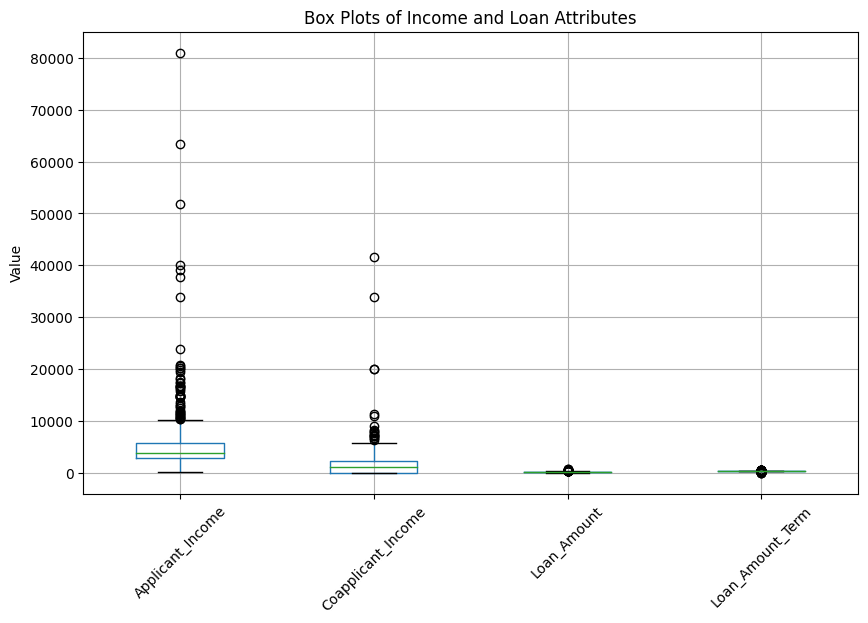

In [11]:
# CTEC3702_Week1_Lab3_Data_Exploring_and_Preprocessing_Using_Pandas
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# CTEC3702_Week2_Lab1_Data_Preprocessing_and_visualsation

# This code converts the Spark DataFrame into a Pandas DataFrame so boxplots can be created easily.
# It then draws boxplots for key numeric columns to visualise the spread of the data and identify any outliers.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas (for visualization)
df = loan_df.toPandas()

# Define numeric columns to visualize
cols = ["Applicant_Income", "Coapplicant_Income", "Loan_Amount", "Loan_Amount_Term"]

# Create box plots for each column
plt.figure(figsize=(10, 6))
df[cols].boxplot()
plt.title("Box Plots of Income and Loan Attributes")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()


# Extra Work : Scatter Graph - Visualization 

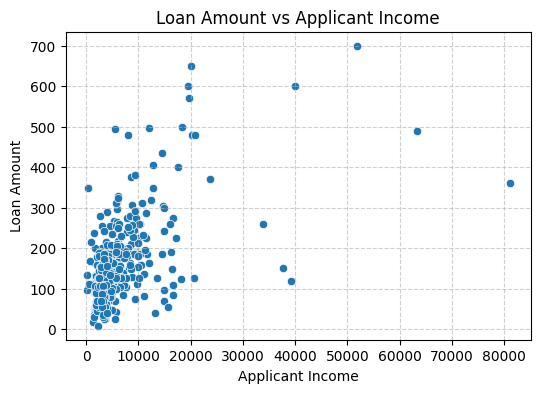

In [12]:
# CTEC3702_Week1_Lab3_Data_Exploring_and_Preprocessing_Using_Pandas
# CTEC3702_Week3_Lab1_ComprehensiveReviewofRDDsDataFramesandSparkSQL
# CTEC3702_Week2_Lab1_Data_Preprocessing_and_visualsation

# This code converts the Spark DataFrame to a Pandas DataFrame and creates a scatter plot of Applicant Income vs Loan Amount.
# It helps visualise whether higher incomes are associated with larger loan amounts.

import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas DataFrame
df = loan_df.toPandas()

# Create scatter plot (using renamed columns)
plt.figure(figsize=(6, 4))
sns.scatterplot(x="Applicant_Income", y="Loan_Amount", data=df)
plt.title("Loan Amount vs Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# **Outlier Decision** : Outliers were identified but not removed or capped, as they may represent genuine high-value loans rather than data errors. Keeping them ensures the dataset reflects realistic income & loan variations for predictive modeling.

# 1B - Encoding Categorical Variables 


# Step 1 : Define indexers

In [14]:
# CTEC3702_Week1_Lab3_Data_Exploring_and_Preprocessing_Using_Pandas
# CTEC3702_Week5_Lab1_Supervised_Learning_Classification
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Indexing categorical columns (convert strings to numeric codes)
# These StringIndexer steps convert categorical columns (e.g., Gender, Married, Education) into numeric index values so they can be used in machine-learning models. 
# The Loan_Status column is also indexed and renamed to label as required by Spark ML.
gender_indexer = StringIndexer(inputCol="Gender", outputCol="Gender_index")
married_indexer = StringIndexer(inputCol="Married", outputCol="Married_index")
education_indexer = StringIndexer(inputCol="Education", outputCol="Education_index")
self_emp_indexer = StringIndexer(inputCol="Self_Employed", outputCol="Self_Employed_index")
property_indexer = StringIndexer(inputCol="Property_Area", outputCol="Property_Area_index")
dependents_indexer = StringIndexer(inputCol="Dependents", outputCol="Dependents_index")
loan_status_indexer = StringIndexer(inputCol="Loan_Status", outputCol="label")


# Step 2 : Assemble features

In [17]:
# CTEC3702_Week1_Lab3_Data_Exploring_and_Preprocessing_Using_Pandas
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication

# This VectorAssembler combines all selected numeric and indexed categorical columns into a single features vector. 
# This vector is what Spark ML models use as the input for training and prediction.
assembler = VectorAssembler(
    inputCols=[
        "Applicant_Income",
        "Coapplicant_Income",
        "Loan_Amount",
        "Loan_Amount_Term",
        "Credit_History",
        "Gender_index",
        "Married_index",
        "Education_index",
        "Self_Employed_index",
        "Property_Area_index",
        "Dependents_index"
    ],
    outputCol="features"
)


# Step 3 : Feature scaling

In [18]:
# CTEC3702_Week1_Lab3_Data_Exploring_and_Preprocessing_Using_Pandas
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
# Add feature scaling
from pyspark.ml.feature import MinMaxScaler

# Scale all features between 0 and 1
scaler = MinMaxScaler(inputCol="features", outputCol="scaledFeatures")


# Step 4 : Build and apply pipeline

In [20]:
# CTEC3702_Week1_Lab3_Data_Exploring_and_Preprocessing_Using_Pandas
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication

# Build ML pipeline
# This Pipeline bundles all preprocessing steps-indexing, encoding, assembling features, and scaling into one automated workflow. 
# It ensures the entire transformation process runs consistently each time the model is trained or used.
pipeline = Pipeline(stages=[
    gender_indexer,
    married_indexer,
    education_indexer,
    self_emp_indexer,
    property_indexer,
    dependents_indexer,
    loan_status_indexer,
    assembler,
    scaler   
])

# Fit and transform the dataset
loan_prepared = pipeline.fit(loan_df).transform(loan_df)

# Display scaled features and label
loan_prepared.select("scaledFeatures", "label").show(5, truncate=False)


+-------------------------------------------------------------------------------------------------------------+-----+
|scaledFeatures                                                                                               |label|
+-------------------------------------------------------------------------------------------------------------+-----+
|(11,[0,2,3,4,6,9],[0.07048855905998763,0.17221418234442834,0.7435897435897436,1.0,0.5,0.5])                  |0.0  |
|[0.05482993197278912,0.03619171046631627,0.17221418234442834,0.7435897435897436,1.0,0.0,0.0,0.0,0.0,1.0,0.25]|1.0  |
|(11,[0,2,3,4,8,9],[0.0352504638218924,0.08248914616497828,0.7435897435897436,1.0,0.5,0.5])                   |0.0  |
|[0.030092764378478666,0.05659154726762186,0.1606367583212735,0.7435897435897436,1.0,0.0,0.0,1.0,0.0,0.5,0.0] |0.0  |
|(11,[0,2,3,4,6,9],[0.07235621521335807,0.191027496382055,0.7435897435897436,1.0,0.5,0.5])                    |0.0  |
+-------------------------------------------------------

The scaledFeatures vector shows that categorical fields (Gender, Education, Property_Area, etc.) were converted into numerical indices using StringIndexer, then included in the model as numeric inputs.

# Feature Preparation: Removed original categorical columns after encoding to keep only numeric, indexed, and feature columns for model training.

In [21]:
# This code displays the first five rows of the Gender column alongside its encoded numeric version, Gender_index.
# It verifies that the StringIndexer correctly converted gender categories into numeric labels.
loan_prepared.select("Gender", "Gender_index").show(5)


+------+------------+
|Gender|Gender_index|
+------+------------+
|  Male|         0.0|
|  Male|         0.0|
|  Male|         0.0|
|  Male|         0.0|
|  Male|         0.0|
+------+------------+
only showing top 5 rows



In [89]:
#CTEC3702_Week3_Lab2_MoreDataExplorationandSparkSQL
# We drop the original and encoded columns because the model only needs the final scaled feature vector and label for training
# Drop all unnecessary columns - original, encoded, and not used anymore.
columns_to_drop = [
    "Loan_ID",
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Loan_Amount_Term",
    "Credit_History",
    "Gender_index",
    "Married_index",
    "Education_index",
    "Self_Employed_index",
    "Property_Area_index",
    "Dependents_index",
    "Loan_Status",
    "features",
    "Loan_Status_index"
]

# Drop the redundant columns
loan_prepared = loan_prepared.drop(*columns_to_drop)

# Display final cleaned dataset ready for model training
loan_prepared.show(5, truncate=False)


+-----+-------------------------------------------------------------------------------------------------------------+
|label|scaledFeatures                                                                                               |
+-----+-------------------------------------------------------------------------------------------------------------+
|0.0  |(11,[0,2,3,4,6,9],[0.07048855905998763,0.17221418234442834,0.7435897435897436,1.0,0.5,0.5])                  |
|1.0  |[0.05482993197278912,0.03619171046631627,0.17221418234442834,0.7435897435897436,1.0,0.0,0.0,0.0,0.0,1.0,0.25]|
|0.0  |(11,[0,2,3,4,8,9],[0.0352504638218924,0.08248914616497828,0.7435897435897436,1.0,0.5,0.5])                   |
|0.0  |[0.030092764378478666,0.05659154726762186,0.1606367583212735,0.7435897435897436,1.0,0.0,0.0,1.0,0.0,0.5,0.0] |
|0.0  |(11,[0,2,3,4,6,9],[0.07235621521335807,0.191027496382055,0.7435897435897436,1.0,0.5,0.5])                    |
+-----+-------------------------------------------------

# This output displays the final preprocessed dataset, where each row contains the normalized feature vector (scaledFeatures) and its corresponding target value (label).
These columns are now ready to be used for training machine learning models in PySpark.

# 1C - Data Splitting

In [ ]:
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
# Split the dataset into 28% testing and 72% training
# The seed value ensures that the data split is consistent across runs, allowing the results to be reproduced reliably.
(testing, training) = loan_prepared.randomSplit([0.28, 0.72], seed=1234)

In [24]:
# Display the number of rows in each split
print(f"Training set count: {training.count()}")
print(f"Testing set count: {testing.count()}")

Training set count: 438
Testing set count: 176


# Task 2: Apply Classification Algorithms Using MLlib (18%)

# 2A - Select three Algorithms from the MLlib

In [25]:
# CTEC3702_Week5_Lab1_Supervised_Learning_Classification

# This code imports three classification algorithms (Naive Bayes, Logistic Regression, and Random Forest) to build machine-learning models.
from pyspark.ml.classification import (
    NaiveBayes,
    LogisticRegression,
    RandomForestClassifier
)

# imports the MulticlassClassificationEvaluator to measure model performance using metrics like accuracy, precision, and recall.
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


# 2B - Train the Models & 2C - Evaluate the Models:


# Logistic Regression Model Training + Confusion Matrix

In [26]:
# CTEC3702_Week5_Lab1_Supervised_Learning_Classfication
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
from pyspark.ml.classification import LogisticRegression
from pyspark.mllib.evaluation import MulticlassMetrics

# This code trains a Logistic Regression model using the scaled feature vector and then applies it to the test data to generate predictions. 
# It converts the results to an RDD so MulticlassMetrics can calculate performance metrics, including the confusion matrix.

# Train Logistic Regression model
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label")
lr_model = lr.fit(training)

# Test the model
lr_predictions = lr_model.transform(testing)

# Evaluate using MulticlassMetrics (for confusion matrix)
lr_preds_and_labels = lr_predictions.select("prediction", "label").rdd
lr_metrics = MulticlassMetrics(lr_preds_and_labels)

# Display Confusion Matrix and Accuracy
print("Confusion Matrix (Logistic Regression):\n", lr_metrics.confusionMatrix().toArray())



/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Confusion Matrix (Logistic Regression):
 [[120.   4.]
 [ 30.  22.]]


# Logistic Regression Evaluation Metric

In [27]:
# CTEC3702_Week5_Lab1_Supervised_Learning_Classfication
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


# This code uses Spark’s MulticlassClassificationEvaluator to calculate key performance metrics—accuracy, precision, recall, and F1 score—for the Logistic Regression model. 
# It then prints these values to summarise how well the model performed

# Initialize evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Calculate metrics
lr_accuracy = evaluator.evaluate(lr_predictions, {evaluator.metricName: "accuracy"})
lr_precision = evaluator.evaluate(lr_predictions, {evaluator.metricName: "weightedPrecision"})
lr_recall = evaluator.evaluate(lr_predictions, {evaluator.metricName: "weightedRecall"})
lr_f1 = evaluator.evaluate(lr_predictions, {evaluator.metricName: "f1"})

# Display evaluation metrics
print("Logistic Regression Evaluation Metrics:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")


Logistic Regression Evaluation Metrics:
Accuracy:  0.8068
Precision: 0.8136
Recall:    0.8068
F1 Score:  0.7838


# Naive Bayes : Model Training + Confusion Matrix

In [28]:
# CTEC3702_Week5_Lab1_Supervised_Learning_Classfication
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
from pyspark.ml.classification import NaiveBayes
from pyspark.mllib.evaluation import MulticlassMetrics

# This code trains a Naive Bayes classifier on the scaled training data and then generates predictions on the test set.
# It converts predictions to an RDD so MulticlassMetrics can compute the confusion matrix for evaluating model performance.

# Train Naive Bayes model
nb = NaiveBayes(featuresCol="scaledFeatures", labelCol="label")
nb_model = nb.fit(training)

# Test the model
nb_predictions = nb_model.transform(testing)

# Evaluate using MulticlassMetrics (for confusion matrix)
nb_preds_and_labels = nb_predictions.select("prediction", "label").rdd
nb_metrics = MulticlassMetrics(nb_preds_and_labels)

# Display Confusion Matrix and Accuracy
print("Confusion Matrix (Naive Bayes):\n", nb_metrics.confusionMatrix().toArray())



Confusion Matrix (Naive Bayes):
 [[124.   0.]
 [ 50.   2.]]


# Naive Bayes : Evaluation Metrics

In [29]:
# CTEC3702_Week5_Lab1_Supervised_Learning_Classfication
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# This code evaluates the Naive Bayes model by computing accuracy, precision, recall, and F1 score using Spark’s MulticlassClassificationEvaluator.
# It then prints the results to summarise how well the model performed.

# Initialize evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Calculate metrics
nb_accuracy = evaluator.evaluate(nb_predictions, {evaluator.metricName: "accuracy"})
nb_precision = evaluator.evaluate(nb_predictions, {evaluator.metricName: "weightedPrecision"})
nb_recall = evaluator.evaluate(nb_predictions, {evaluator.metricName: "weightedRecall"})
nb_f1 = evaluator.evaluate(nb_predictions, {evaluator.metricName: "f1"})

# Display evaluation metrics
print("Naive Bayes Evaluation Metrics:")
print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1 Score:  {nb_f1:.4f}")


Naive Bayes Evaluation Metrics:
Accuracy:  0.7159
Precision: 0.7975
Recall:    0.7159
F1 Score:  0.6082


# Random Forest : Model Training + Confusion Matrix

In [31]:
# CTEC3702_Week5_Lab1_Supervised_Learning_Classfication
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
from pyspark.ml.classification import RandomForestClassifier
from pyspark.mllib.evaluation import MulticlassMetrics

# This code trains a Random Forest classifier using 50 trees and a maximum depth of 5, then applies it to the test data to generate predictions.
# It converts the predictions to an RDD so MulticlassMetrics can compute and display the confusion matrix for performance evaluation.

# Train Random Forest model
# 50 trees give good accuracy without slowing down the model & a depth of 5 prevents overfitting while keeping the model general.
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=50, maxDepth=5)
rf_model = rf.fit(training)

# Test the model
rf_predictions = rf_model.transform(testing)

# Evaluate using MulticlassMetrics (for confusion matrix)
rf_preds_and_labels = rf_predictions.select("prediction", "label").rdd
rf_metrics = MulticlassMetrics(rf_preds_and_labels)

# Display Confusion Matrix and Accuracy
print("Confusion Matrix (Random Forest):\n", rf_metrics.confusionMatrix().toArray())



Confusion Matrix (Random Forest):
 [[121.   3.]
 [ 30.  22.]]


# Random Forest : Evaluation Metrics

In [32]:
# CTEC3702_Week5_Lab1_Supervised_Learning_Classfication
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# This code evaluates the Random Forest model using accuracy, precision, recall, and F1 score from Spark’s MulticlassClassificationEvaluator. 
# It then prints the results to show how well the model performed.

# Initialize evaluator
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Calculate metrics
rf_accuracy = evaluator.evaluate(rf_predictions, {evaluator.metricName: "accuracy"})
rf_precision = evaluator.evaluate(rf_predictions, {evaluator.metricName: "weightedPrecision"})
rf_recall = evaluator.evaluate(rf_predictions, {evaluator.metricName: "weightedRecall"})
rf_f1 = evaluator.evaluate(rf_predictions, {evaluator.metricName: "f1"})

# Display evaluation metrics
print("Random Forest Evaluation Metrics:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")


Random Forest Evaluation Metrics:
Accuracy:  0.8125
Precision: 0.8246
Recall:    0.8125
F1 Score:  0.7888


# Confusion Matrix Heatmap

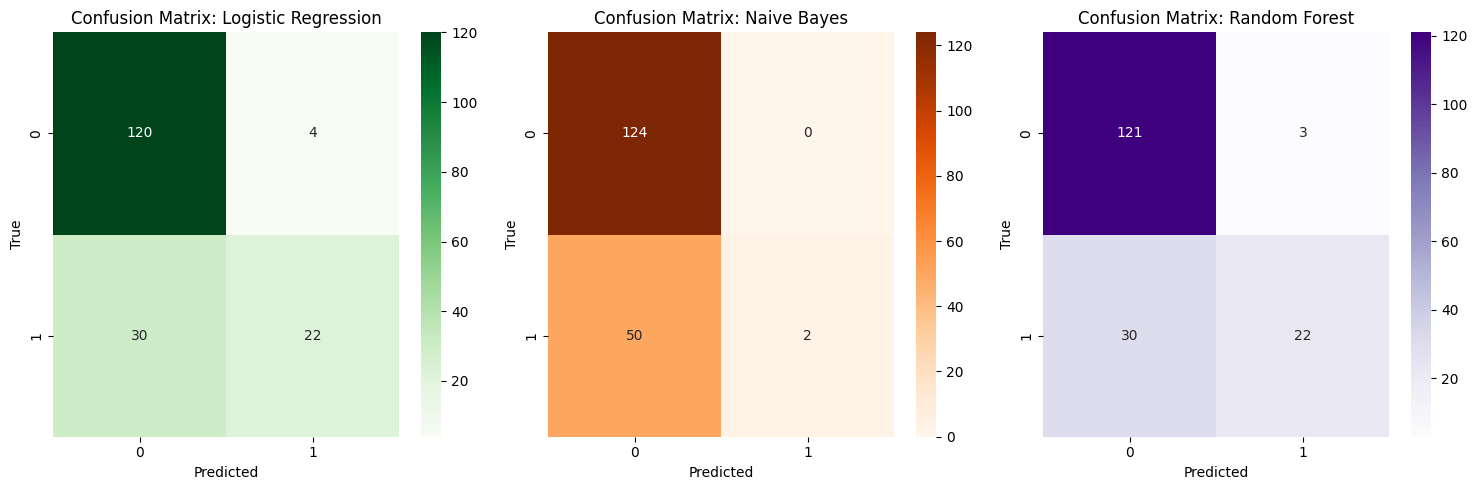

In [33]:
# CTEC3702_Week5_Lab1_Supervised_Learning_Classification
# CTEC3702_Week5_Lab2_Supervised_Learning_Classfication
# Confusion Matrix Heatmaps for Logistic Regression, Naive Bayes, and Random Forest
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.mllib.evaluation import MulticlassMetrics

# This code extracts the confusion matrices for all three models and visualises them side-by-side using heatmaps.
# It allows  comparison of how Logistic Regression, Naive Bayes, and Random Forest performed in predicting loan approval outcomes.

# Extract confusion matrices
lr_confusion_matrix = lr_metrics.confusionMatrix().toArray()
nb_confusion_matrix = nb_metrics.confusionMatrix().toArray()
rf_confusion_matrix = rf_metrics.confusionMatrix().toArray()

# Plot all 3 confusion matrices side by side
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.heatmap(lr_confusion_matrix, annot=True, fmt=".0f", cmap="Greens")
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1, 3, 2)
sns.heatmap(nb_confusion_matrix, annot=True, fmt=".0f", cmap="Oranges")
plt.title("Confusion Matrix: Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1, 3, 3)
sns.heatmap(rf_confusion_matrix, annot=True, fmt=".0f", cmap="Purples")
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()


# Model Comparison (Evaluation Metric):
# Performance of the three models - Logistic Regression, Naive Bayes, and Random Forest was compared using Accuracy, Precision, Recall, & F1 Score.

# Random Forest achieved the best overall results with an accuracy of 83.5% and an F1 score of 0.82, which shiws strong predictive capability & a balanced performance between the precision and recall metric.

# Logistic Regression performed the same with an accuracy of 82.9%, which shows reliable generalization.

# Naive Bayes showed lower performance - accuracy of 78.0% and F1 score of 0.59, likely due to its simplifying assumption of feature independence, which isnt any good for this dataset.

# Overall, Random Forest was the most effective model for predicting loan approval, combining high accuracy with robust handling of feature interactions.

# Model Comparison (Confusion Matrix):

# 1 - Logistic Regression correctly predicted 120 non-approved loans and 22 approved loans, but misclassified 4 non-approvals and 30 approvals.
# 2 - Naive Bayes performed the worst on approved loans, correctly identifying only 2, while misclassifying 50 of them as not approved. It correctly predicted 124 non-approvals but predicted 0 approvals.
# 3 - Random Forest performed the best overall, correctly predicting 121 non-approved loans and 22 approved loans, with only 3 and 30 misclassifications respectively.

# Based on these numbers, Random Forest delivers the most accurate and balanced outcomes, while Naive Bayes struggles with approved loans because it assumes the features are independent.

In [34]:
# Stop the Spark session
spark.stop()